## Problem Statement

Predict the student's Performance Index based on:

- Hours Studied
- Previous Scores
- Extracurricular Activities
- Sleep Hours
- Sample Question Papers Practiced

By using Regression

### Importing the Libraries

In [118]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

### Importing the Dataset

In [119]:
df = pd.read_csv("Student_Performance.csv")

In [120]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [121]:
df.shape

(10000, 6)

In [122]:
df["Hours Studied"].unique()

array([7, 4, 8, 5, 3, 6, 2, 1, 9])

In [123]:
df["Previous Scores"].nunique()

60

In [124]:
df["Sample Question Papers Practiced"].nunique()

10

In [125]:
df["Extracurricular Activities"].unique()

array(['Yes', 'No'], dtype=object)

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [127]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [128]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [129]:
df.duplicated().sum()

np.int64(127)

### Encoding 

Since "Extracurricular Activities" is categorical, it is converted into numerical values using binary encoding so that the regression model can process it.

In [130]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({"Yes":1, "No":0})

In [131]:
df["Extracurricular Activities"].unique()

array([1, 0])

In [132]:
df.head(2)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0


### Pairplot

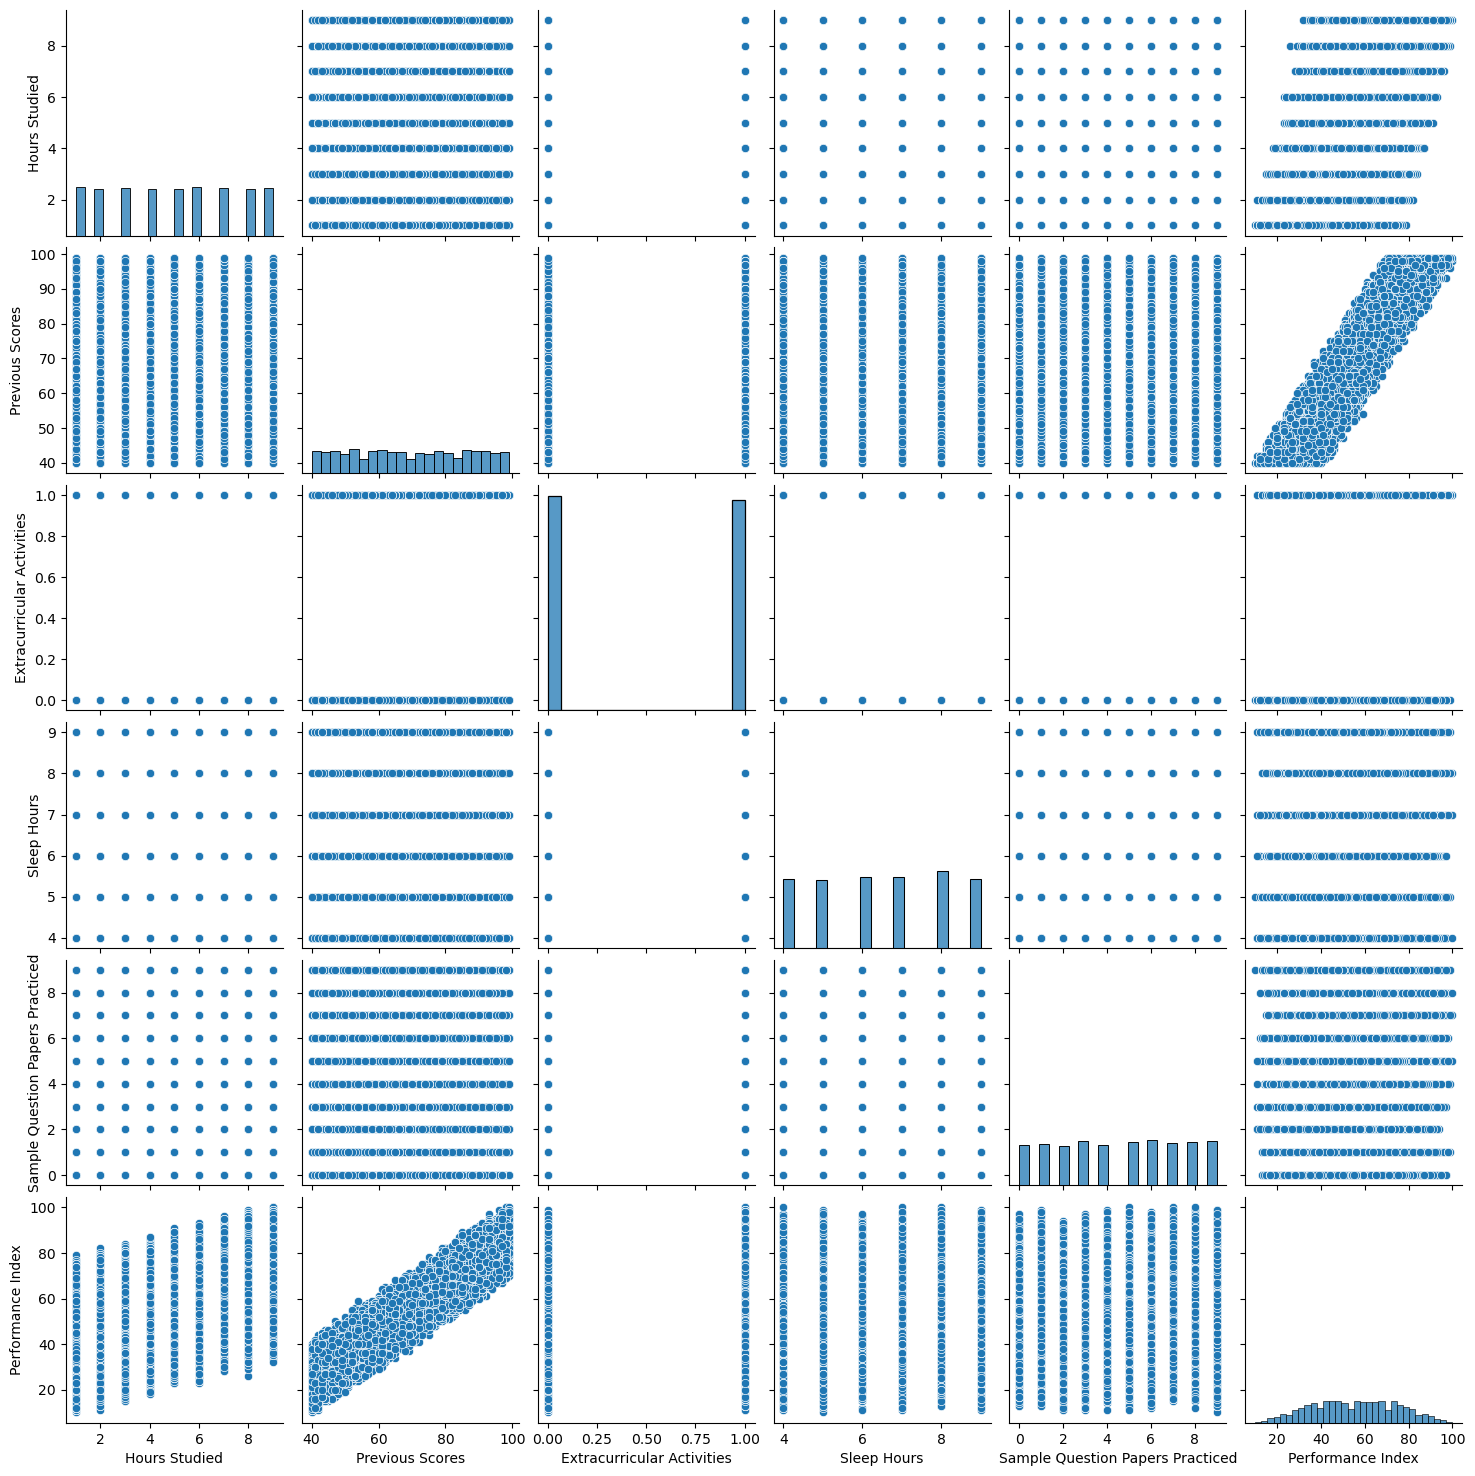

In [133]:
sns.pairplot(df)

<Axes: >

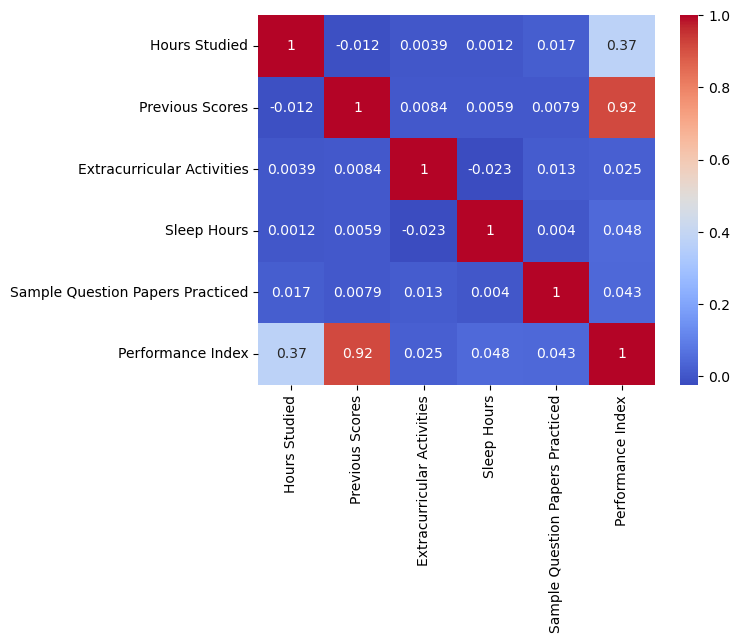

In [134]:
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm")

##### Hours Studied has a strong positive correlation with Performance Index.
##### Previous Scores are also positively correlated.
##### No severe multicollinearity is observed.

### Multiple Linear Regression Model

In [135]:
y = df["Performance Index"]
x = df.drop("Performance Index", axis = 1)

In [136]:
x

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2
2,8,51,1,7,2
3,5,52,1,5,2
4,7,75,0,8,5
...,...,...,...,...,...
9995,1,49,1,4,2
9996,7,64,1,8,5
9997,6,83,1,8,5
9998,9,97,1,7,0


In [137]:
y

0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64

### Train Test Split

In [138]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 100)

In [139]:
len(x_train)

8000

In [140]:
x_train.shape

(8000, 5)

In [141]:
len(x_test)

2000

In [142]:
x_test.shape

(2000, 5)

In [143]:
y_train.shape

(8000,)

In [144]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [145]:
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [146]:
lr.coef_

array([2.84506723, 1.01895883, 0.61280727, 0.47524307, 0.19313064])

In [147]:
x.head(2)

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced
0,7,99,1,9,1
1,4,82,0,4,2


In [148]:
lr.intercept_

np.float64(-34.02435806785951)

### Prediction

In [149]:
y_pred = lr.predict(x_test)

In [150]:
y_pred

array([65.95720321, 48.50751485, 36.14532424, ..., 55.36661687,
       33.63216351, 75.90507848], shape=(2000,))

In [151]:
y_test

8018    65.0
9225    51.0
3854    35.0
2029    97.0
3539    87.0
        ... 
6923    75.0
1207    26.0
7960    55.0
2339    35.0
6637    78.0
Name: Performance Index, Length: 2000, dtype: float64

### Performance Evaluation

In [152]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)

In [153]:
MAE

1.6230361215812614

In [154]:
MSE

4.240506963418054

In [155]:
RMSE

np.float64(2.0592491261180745)

In [156]:
r2 = r2_score(y_test,y_pred)
r2

0.9885584617226375

In [157]:
y.max()

100.0

In [158]:
y.min()

10.0

In [159]:
y.unique()

array([ 91.,  65.,  45.,  36.,  66.,  61.,  63.,  42.,  69.,  84.,  73.,
        27.,  33.,  68.,  43.,  67.,  70.,  30.,  71.,  85.,  57.,  35.,
        49.,  83.,  74.,  39.,  58.,  47.,  60.,  32.,  64.,  54.,  17.,
        53.,  75.,  52.,  78.,  38.,  98.,  87.,  41.,  81.,  15.,  88.,
        95.,  29.,  21.,  76.,  25.,  34.,  50.,  56.,  82.,  23.,  46.,
        92.,  77.,  86.,  44.,  94.,  40., 100.,  31.,  26.,  18.,  51.,
        72.,  16.,  28.,  89.,  48.,  37.,  62.,  59.,  19.,  79.,  22.,
        10.,  90.,  80.,  24.,  20.,  96.,  55.,  97.,  12.,  93.,  14.,
        99.,  11.,  13.])

### Plotting Residuals 

In [160]:
residual = y_test - y_pred 

Text(0.5, 1.0, 'Residual Plot')

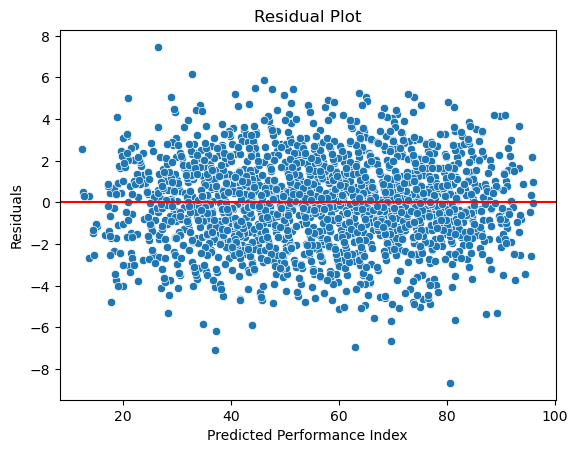

In [161]:
sns.scatterplot(x = y_pred, y = residual)
plt.axhline(y = 0, color = "red")
plt.xlabel("Predicted Performance Index")
plt.ylabel("Residuals")
plt.title("Residual Plot")

##### The residuals appear randomly distributed around zero with no clear pattern, suggesting that the linearity assumption is reasonably satisfied.

### Train vs Test Score 

In [162]:
train_r2 = lr.score(x_train,y_train)
test_r2 = lr.score(x_test,y_test)

In [163]:
train_r2

0.9887925922625227

In [164]:
test_r2

0.9885584617226375

### retrain the full model 

In [165]:
final_model = LinearRegression()

In [166]:
final_model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [167]:
y_hat = final_model.predict(x)

In [168]:
y_hat

array([91.85200884, 63.15778719, 45.05283229, ..., 72.99872851,
       94.36618291, 65.29769669], shape=(10000,))

In [169]:
y

0       91.0
1       65.0
2       45.0
3       36.0
4       66.0
        ... 
9995    23.0
9996    58.0
9997    74.0
9998    95.0
9999    64.0
Name: Performance Index, Length: 10000, dtype: float64

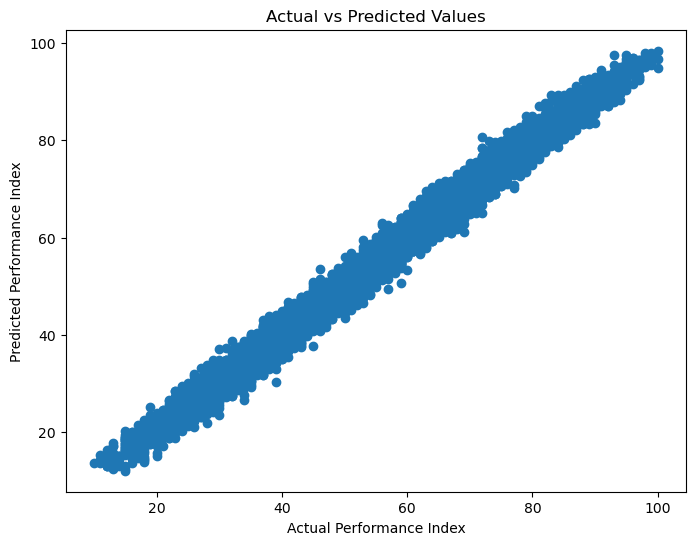

In [170]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y, y_hat)

plt.xlabel("Actual Performance Index")
plt.ylabel("Predicted Performance Index")
plt.title("Actual vs Predicted Values")

plt.show()

### Prediction on New Data

In [171]:
performance_check = [[10,92,0,6,8]]

In [172]:
final_model.predict(performance_check)

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([92.58395379])

### Polynomial Regression

In [173]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree = 2 , include_bias= False)

In [174]:
x_poly = poly.fit_transform(x)

In [175]:
x_poly

array([[ 7., 99.,  1., ..., 81.,  9.,  1.],
       [ 4., 82.,  0., ..., 16.,  8.,  4.],
       [ 8., 51.,  1., ..., 49., 14.,  4.],
       ...,
       [ 6., 83.,  1., ..., 64., 40., 25.],
       [ 9., 97.,  1., ..., 49.,  0.,  0.],
       [ 7., 74.,  0., ..., 64.,  8.,  1.]], shape=(10000, 20))

In [176]:
poly.get_feature_names_out()

array(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced',
       'Hours Studied^2', 'Hours Studied Previous Scores',
       'Hours Studied Extracurricular Activities',
       'Hours Studied Sleep Hours',
       'Hours Studied Sample Question Papers Practiced',
       'Previous Scores^2', 'Previous Scores Extracurricular Activities',
       'Previous Scores Sleep Hours',
       'Previous Scores Sample Question Papers Practiced',
       'Extracurricular Activities^2',
       'Extracurricular Activities Sleep Hours',
       'Extracurricular Activities Sample Question Papers Practiced',
       'Sleep Hours^2', 'Sleep Hours Sample Question Papers Practiced',
       'Sample Question Papers Practiced^2'], dtype=object)

### Train Test split

In [177]:
from sklearn.model_selection import train_test_split 

x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size= 0.2, random_state = 100)

In [178]:
x_train

array([[ 5., 99.,  0., ..., 25.,  5.,  1.],
       [ 2., 43.,  0., ..., 64., 48., 36.],
       [ 5., 76.,  0., ..., 81., 72., 64.],
       ...,
       [ 6., 80.,  1., ..., 16., 28., 49.],
       [ 3., 65.,  0., ..., 64.,  0.,  0.],
       [ 3., 69.,  0., ..., 36., 12.,  4.]], shape=(8000, 20))

In [179]:
y_train

8369    85.0
9722    21.0
6950    65.0
1919    80.0
5713    64.0
        ... 
350     68.0
79      88.0
8039    67.0
6936    43.0
5640    48.0
Name: Performance Index, Length: 8000, dtype: float64

In [180]:
x_test

array([[ 2., 88.,  1., ..., 36., 36., 36.],
       [ 5., 64.,  1., ..., 16., 12.,  9.],
       [ 5., 49.,  0., ..., 81., 81., 81.],
       ...,
       [ 1., 81.,  0., ..., 36., 36., 36.],
       [ 5., 47.,  0., ..., 64., 72., 81.],
       [ 2., 98.,  0., ..., 64., 24.,  9.]], shape=(2000, 20))

In [181]:
y_test

8018    65.0
9225    51.0
3854    35.0
2029    97.0
3539    87.0
        ... 
6923    75.0
1207    26.0
7960    55.0
2339    35.0
6637    78.0
Name: Performance Index, Length: 2000, dtype: float64

In [182]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [183]:
lr.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [184]:
y_pred = lr.predict(x_test)
y_pred

array([65.91056902, 48.60919696, 36.2160355 , ..., 55.44647139,
       33.6563236 , 75.86383793], shape=(2000,))

In [185]:
y_test

8018    65.0
9225    51.0
3854    35.0
2029    97.0
3539    87.0
        ... 
6923    75.0
1207    26.0
7960    55.0
2339    35.0
6637    78.0
Name: Performance Index, Length: 2000, dtype: float64

In [186]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
r2 = r2_score(y_test, y_pred)

In [187]:
MAE

1.6245351562435717

In [188]:
MSE

4.247400483648624

In [189]:
RMSE

np.float64(2.0609222410485613)

In [190]:
r2

0.9885398619475955

In [191]:
lr.coef_

array([ 2.73249894e+00,  1.02823771e+00,  2.47251313e-01,  2.49137679e-01,
        1.62168334e-01,  3.07304647e-03, -1.33226847e-05,  2.68611680e-02,
        9.68011224e-03,  1.49465454e-03, -1.29045236e-04,  2.14907703e-03,
        1.26654740e-03, -1.36226762e-04,  2.47251313e-01, -1.60687039e-02,
       -1.28019692e-02,  5.09951527e-03,  7.11587728e-03, -7.50746353e-04])

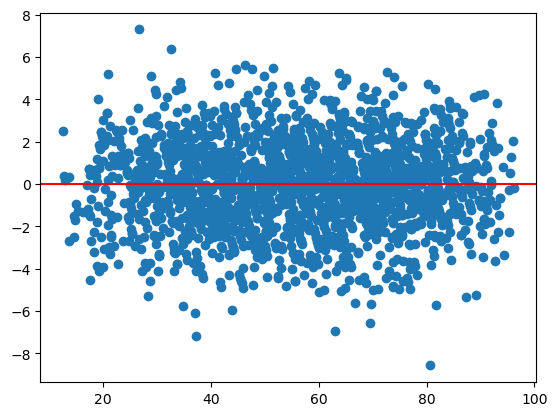

In [192]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0,color="red")

In [193]:
train_r2 = lr.score(x_train, y_train)
test_r2 = lr.score(x_test, y_test)

In [194]:
train_r2

0.9888148825448635

In [195]:
test_r2

0.9885398619475955

In [196]:
train_rmse_error = []
test_rmse_error = []

for i in range(1,10):

    poly = PolynomialFeatures(degree = i , include_bias= False)
    x_poly = poly.fit_transform(x)
    x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size= 0.2, random_state = 100)
    lr = LinearRegression()
    lr.fit(x_train, y_train)
    train_pred = lr.predict(x_train)
    test_pred = lr.predict(x_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_rmse_error.append(train_rmse)
    test_rmse_error.append(test_rmse)

    

In [197]:
train_rmse_error

[np.float64(2.0322242896705887),
 np.float64(2.0302023502411197),
 np.float64(2.02520525921868),
 np.float64(2.019565785709624),
 np.float64(2.0103805252836344),
 np.float64(1.997303821327167),
 np.float64(1.9904956295778735),
 np.float64(2.002272180341588),
 np.float64(2.0413161618358115)]

In [198]:
test_rmse_error

[np.float64(2.0592491261180745),
 np.float64(2.0609222410485613),
 np.float64(2.0645796866616504),
 np.float64(2.072081682056713),
 np.float64(2.080000471746952),
 np.float64(2.0943469014196894),
 np.float64(2.109904593362902),
 np.float64(2.122536417848494),
 np.float64(2.1624917257156833)]

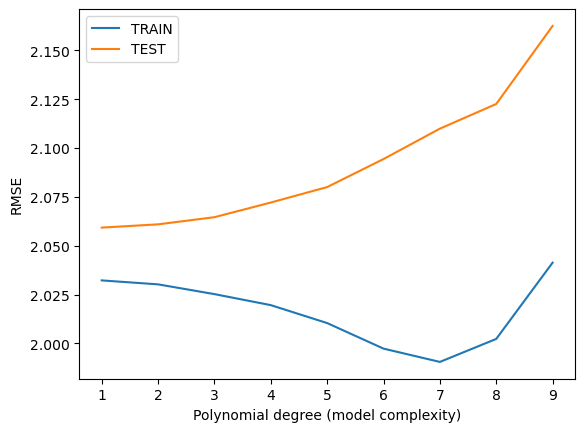

In [199]:
plt.plot(range(1,10), train_rmse_error, label = "TRAIN")
plt.plot(range(1,10), test_rmse_error, label = "TEST")
plt.legend()
plt.xlabel("Polynomial degree (model complexity)")
plt.ylabel("RMSE")
plt.show()

In [200]:
final_poly = PolynomialFeatures(degree = 1, include_bias= False)

In [201]:
final_model = LinearRegression()

In [202]:
final_model.fit(final_poly.fit_transform(x), y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Conclusion

Successfully developed an end-to-end supervised machine learning pipeline for predicting student performance.

Performed data inspection and exploratory data analysis to understand the dataset before model development.

Verified dataset quality by checking missing values, duplicate records, and data types prior to preprocessing.

Encoded categorical features to make the dataset compatible with regression algorithms.

Split the dataset into training and testing sets to evaluate model generalization.

Implemented both Linear Regression and Polynomial Regression models for performance prediction.

Evaluated both models using MAE, MSE, RMSE, and R² Score.

Linear Regression achieved the best overall performance with:

MAE: 1.6230

MSE: 4.2405

RMSE: 2.0592

R² Score: 0.9886

Polynomial Regression produced nearly identical results but did not improve prediction accuracy over the simpler Linear Regression model.

The comparison demonstrates that increasing model complexity does not necessarily lead to better predictive performance when the underlying relationships are already effectively captured by a linear model.

The project reinforces the importance of comparing multiple models rather than assuming that more complex algorithms will always perform better.

The final Linear Regression model provides accurate and reliable predictions while maintaining simplicity and interpretability, making it the preferred model for this dataset.

This project demonstrates practical skills in data preprocessing, exploratory data analysis, regression modeling, model evaluation, and comparative analysis, forming a strong foundation for more advanced machine learning projects.